<a href="https://colab.research.google.com/github/Balajivallepu/DL/blob/main/conventional_Auto_encoder2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil #moving and coping files
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [ ]:
import kagglehub

path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset download txt",path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset download txt /kaggle/input/celeba-dataset


In [ ]:
import os
import shutil #moving and coping files

#create a smaller Dataset (500 Images)
source_folder =os.path.join(path,"img_align_celeba","img_align_celeba")

destination_folder="celeda_small/faces"

os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder,img),
        os.path.join(destination_folder,img),
    )
print("Copied",len(images),"images")

Copied 5000 images


In [ ]:
#Data preprocessing
#changed batch size from 64 to 128
IMAGE_SIZE=(128,128)

BATCH_SIZE=64

In [ ]:
datagen =ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2

)

In [ ]:
#Load Dataset
train_generator =datagen.flow_from_directory(
    "celeda_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator =datagen.flow_from_directory(
    "celeda_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


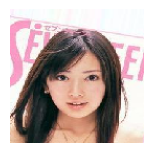

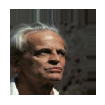

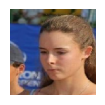

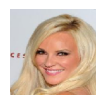

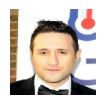

In [ ]:
#Display Sample Images
images, _ =next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

In [ ]:
input_img =Input(shape=(128,128,3))
x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(input_img)
x=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)
x=Conv2D(
    128,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)
x=Conv2D(
    256,
    (3,3),
    activation="relu",
    padding="same"
)(x)
encoded=MaxPooling2D(
 (2,2),
 padding="same"
)(x)

In [ ]:
x=Conv2D(
    256,
    (3,3),
    activation="relu",
    padding="same"
)(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    128,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(
    3,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

In [ ]:
#create model
autoencoder=Model(
    input_img,
    decoded
)

In [ ]:
#compie model
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")

In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train model
history=autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 522ms/step - loss: 0.5611 - val_loss: 0.5034
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - loss: 0.4953 - val_loss: 0.4908
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - loss: 0.4894 - val_loss: 0.4878
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - loss: 0.4878 - val_loss: 0.4861
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - loss: 0.4844 - val_loss: 0.4860
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - loss: 0.4834 - val_loss: 0.4823
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - loss: 0.4845 - val_loss: 0.4827
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - loss: 0.4821 - val_loss: 0.4834
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - loss: 0.4815 - val_loss: 0.4864
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - loss: 0.4814 - val_loss: 0.4825
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - loss: 0.4802 - val_loss: 0.4803
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11

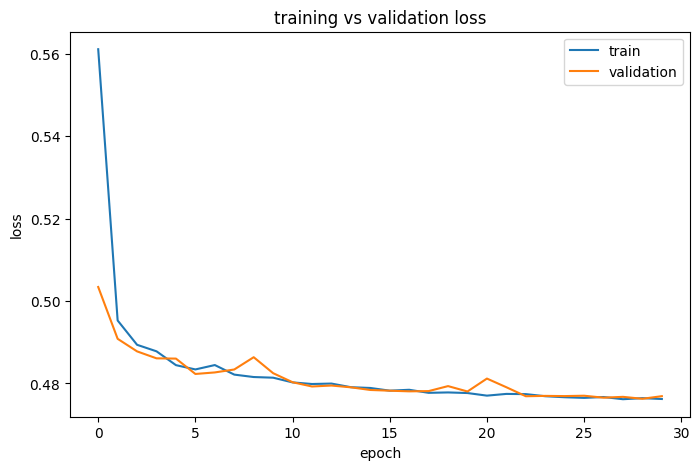

In [ ]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
#evaluate model
loss=autoencoder.evaluate(validation_generator)
print("validation loss",loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.4769
validation loss 0.47690337896347046


In [ ]:
#reconstruct images
images,_=next(validation_generator)
reconstructed_images=autoencoder.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


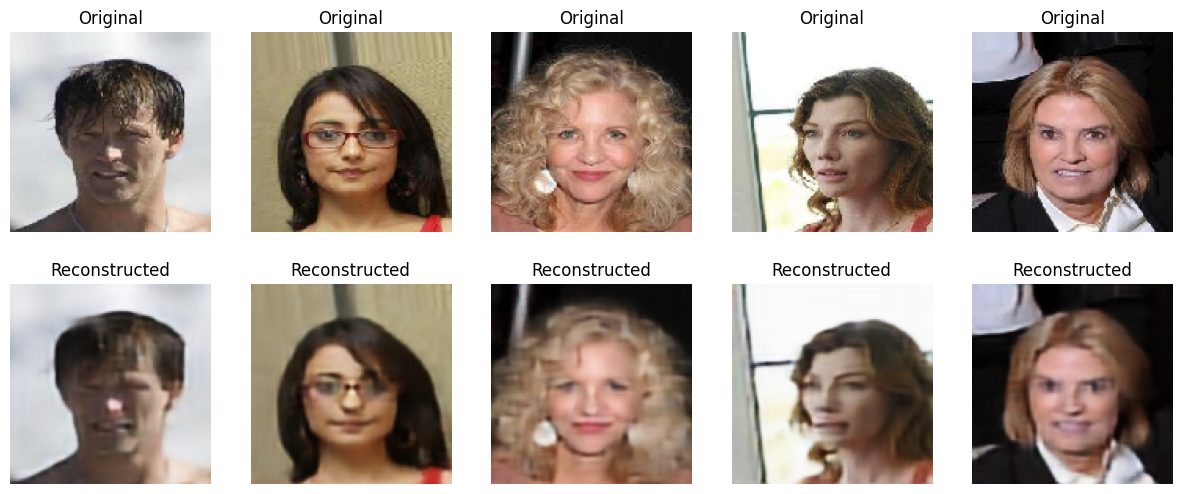

In [ ]:
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+n+1)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()

